[2026-07-08 15:36:28] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-08 15:36:31] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-08 15:36:31] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-08 15:36:32] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-08 15:36:32] [info     ] ========== 数据检查 ==========
[2026-07-08 15:36:32] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflow_amount_main', 'netflow_amount_rate_main', 'net_act

时段,IC
2024-01-15~2024-02-08,-0.0062
2024-09-24~2024-10-08,-0.0197

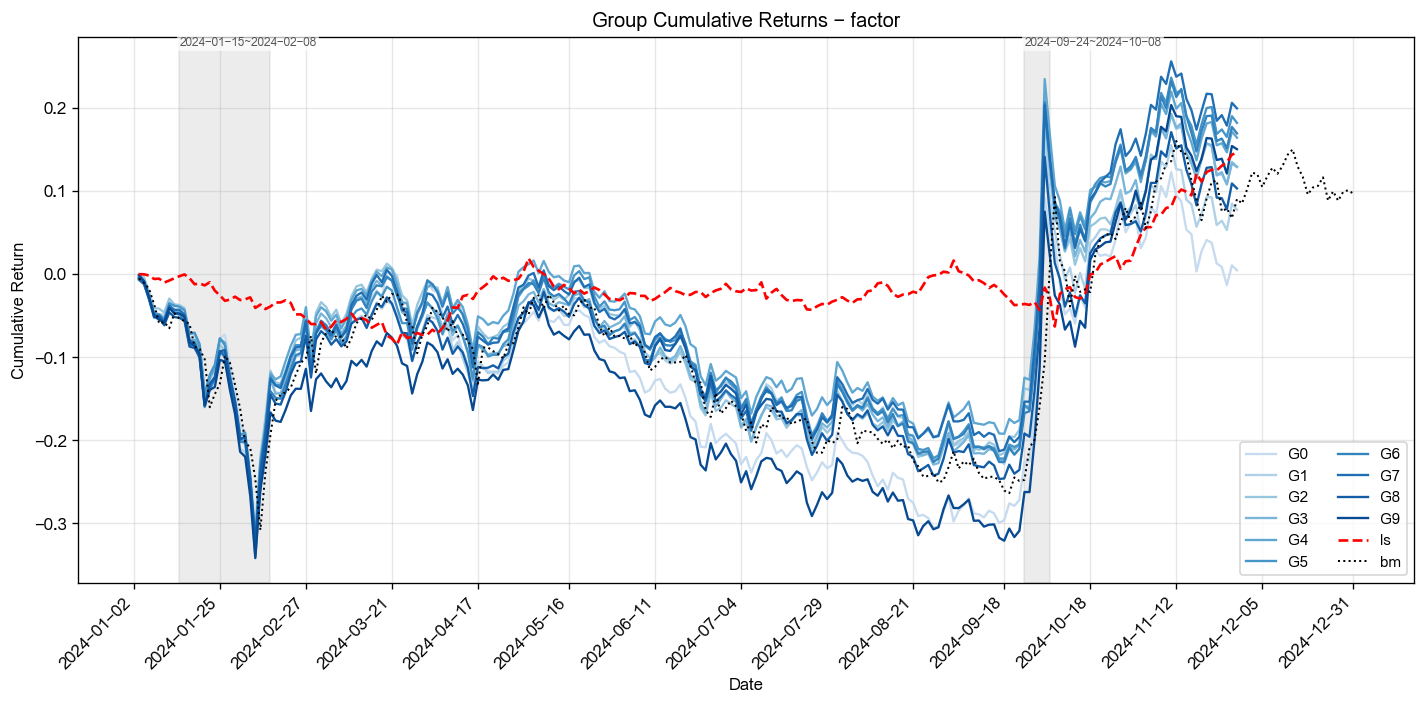
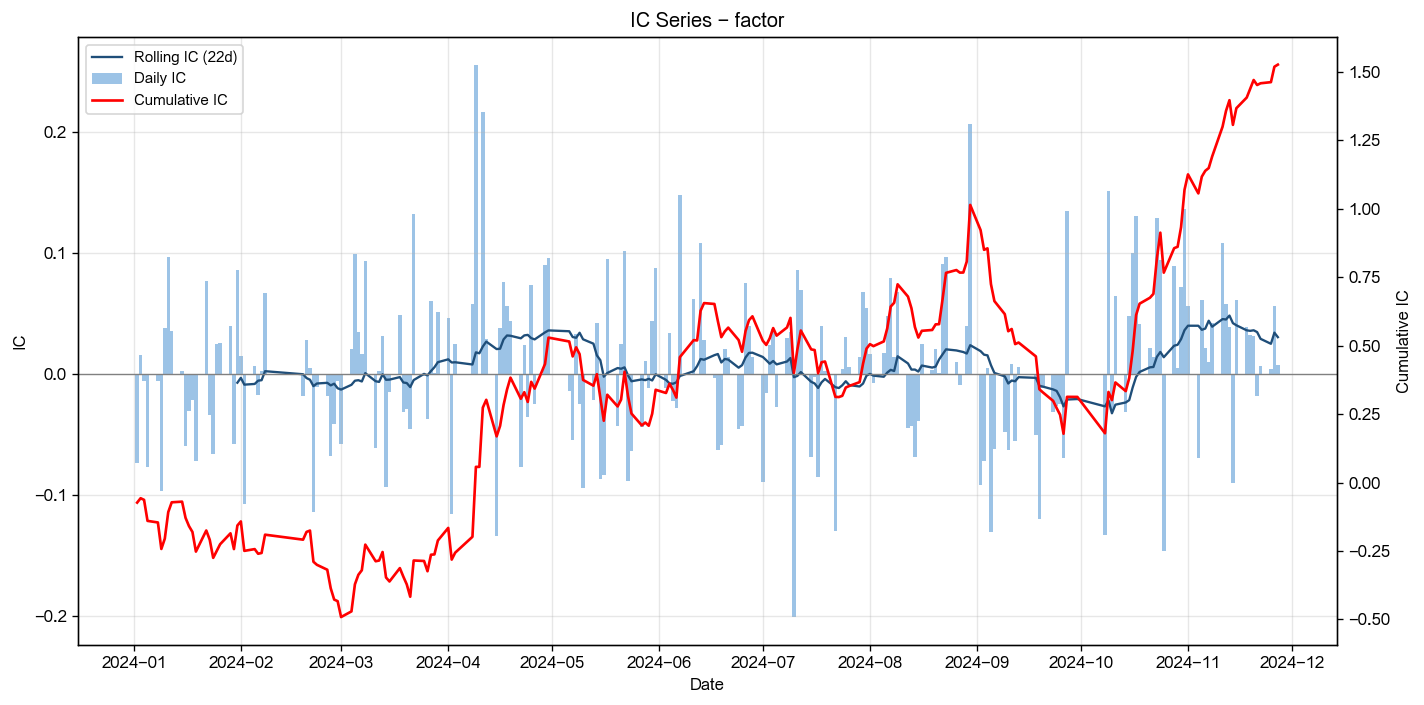
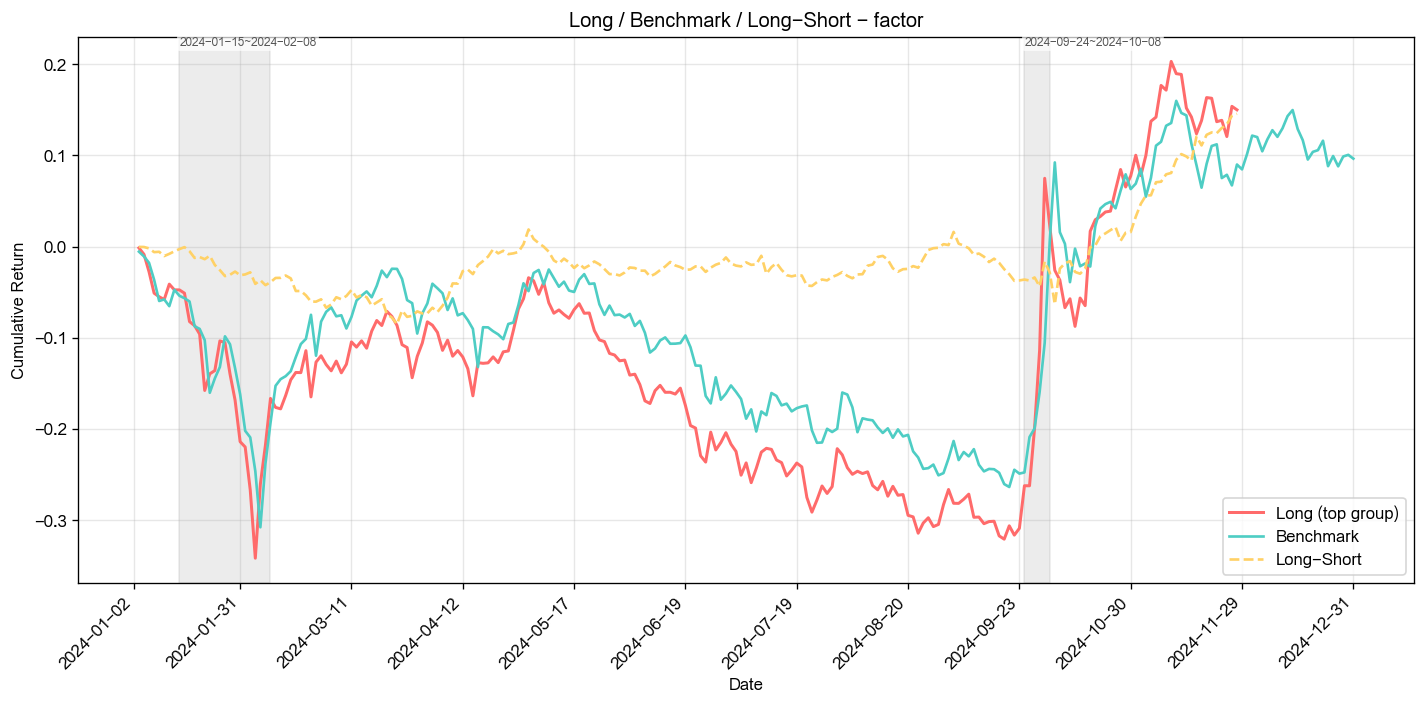
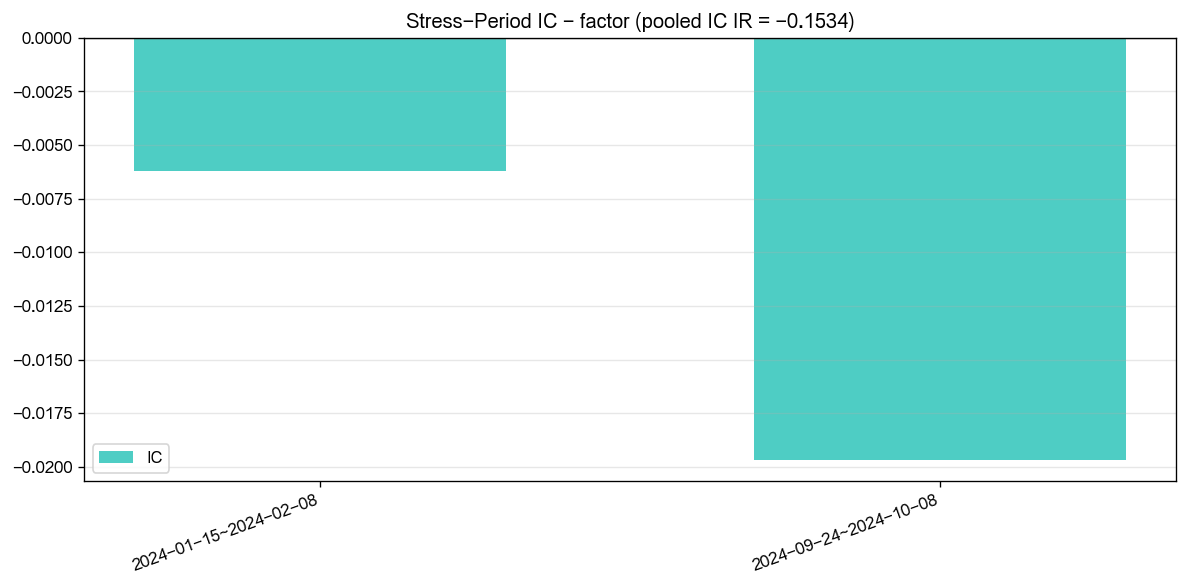
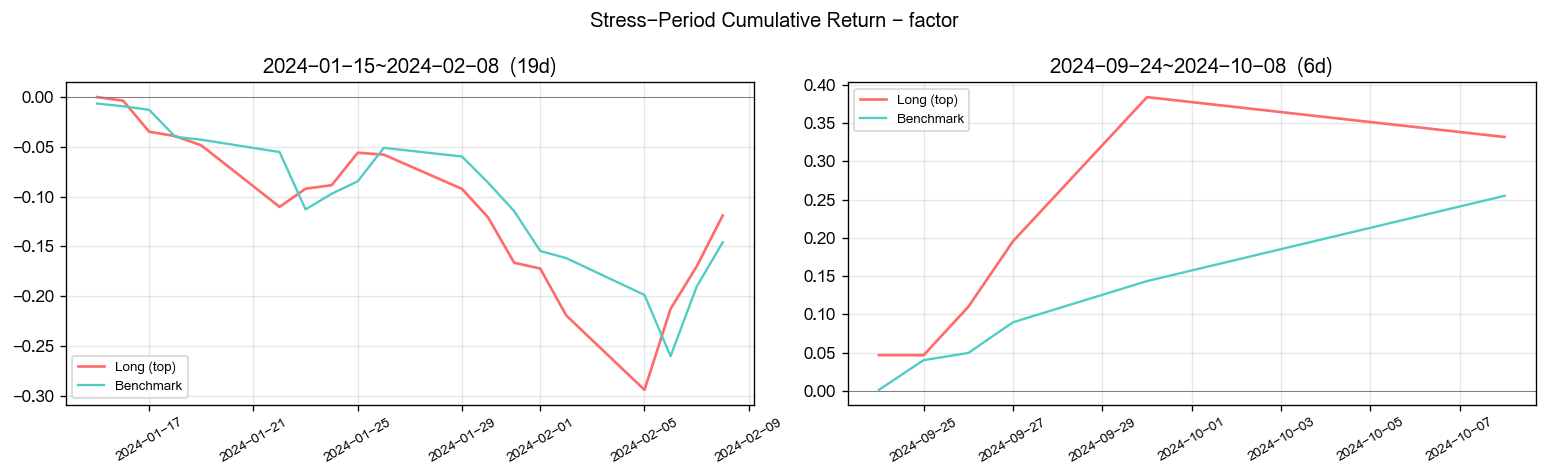

[2026-07-08 15:36:50] [info     ] ========== 因子池回归 ==========
[2026-07-08 15:36:50] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-08 15:36:51] [info     ] 获取收益率数据, 耗时: 1.8179 秒
[2026-07-08 15:36:52] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.2571 秒
[2026-07-08 15:36:52] [info     ] 统计 回归结果, 耗时: 0.0973 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9582,0.0448,0.0229,1.0000
2,amount,1.7059,0.0186,0.0109,1.0000
3,factor,1.6413,0.0059,0.0036,1.0000
4,netflow_amount_main,1.5503,0.0254,0.0164,1.0000
5,gross_profit_rate_ttm,1.5104,0.0069,0.0046,1.0000
6,netflow_amount_rate_main,1.5087,0.0099,0.0065,1.0000
7,net_profit_rate_ttm,1.4441,0.0040,0.0028,0.8000
8,cci_14,1.4273,0.0340,0.0238,1.0000
9,pb,1.4215,0.0097,0.0068,1.0000
10,bias_20,1.4184,0.0292,0.0206,0.9000

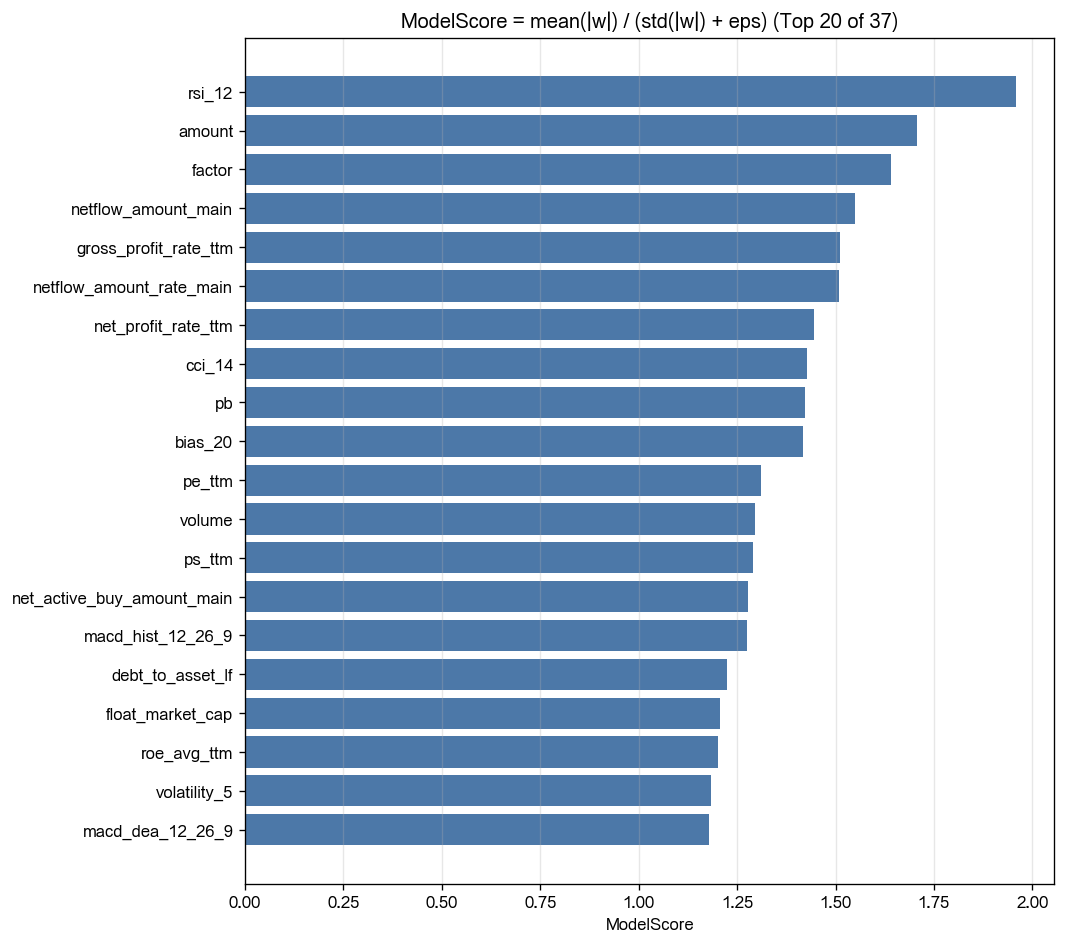
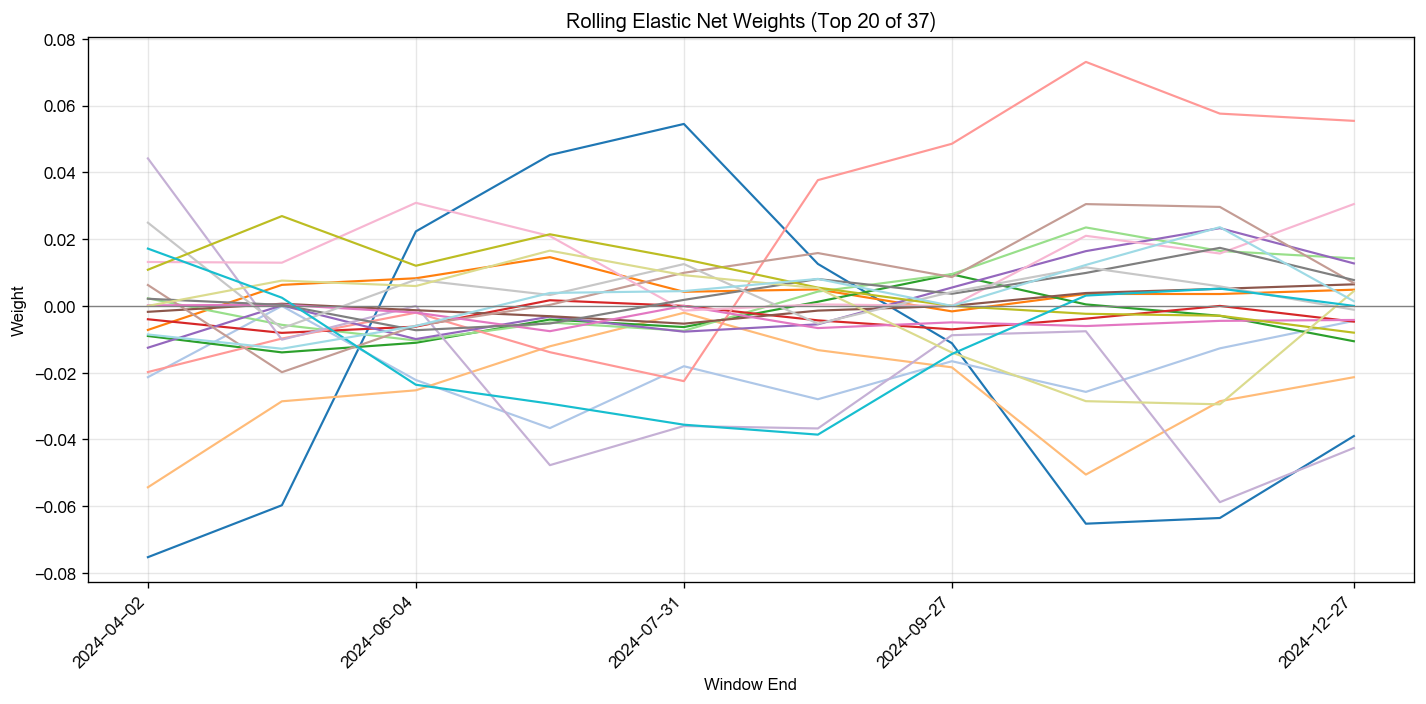
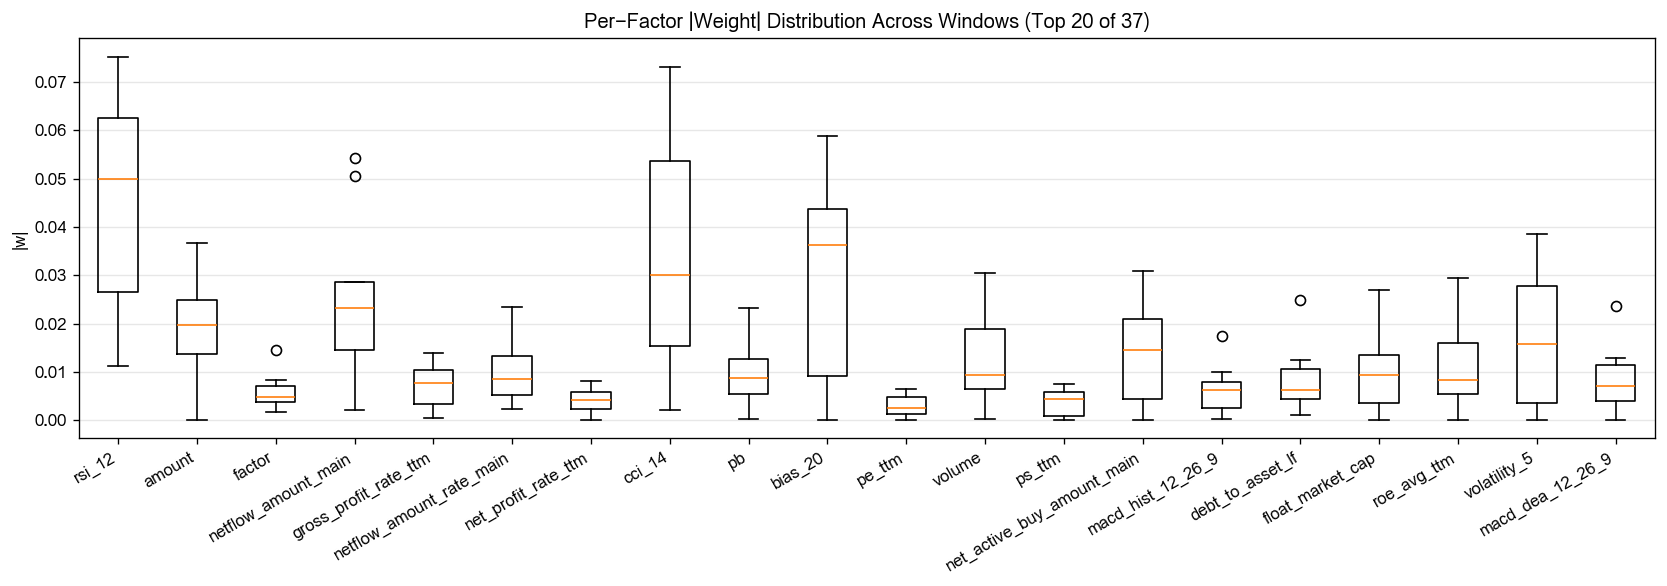
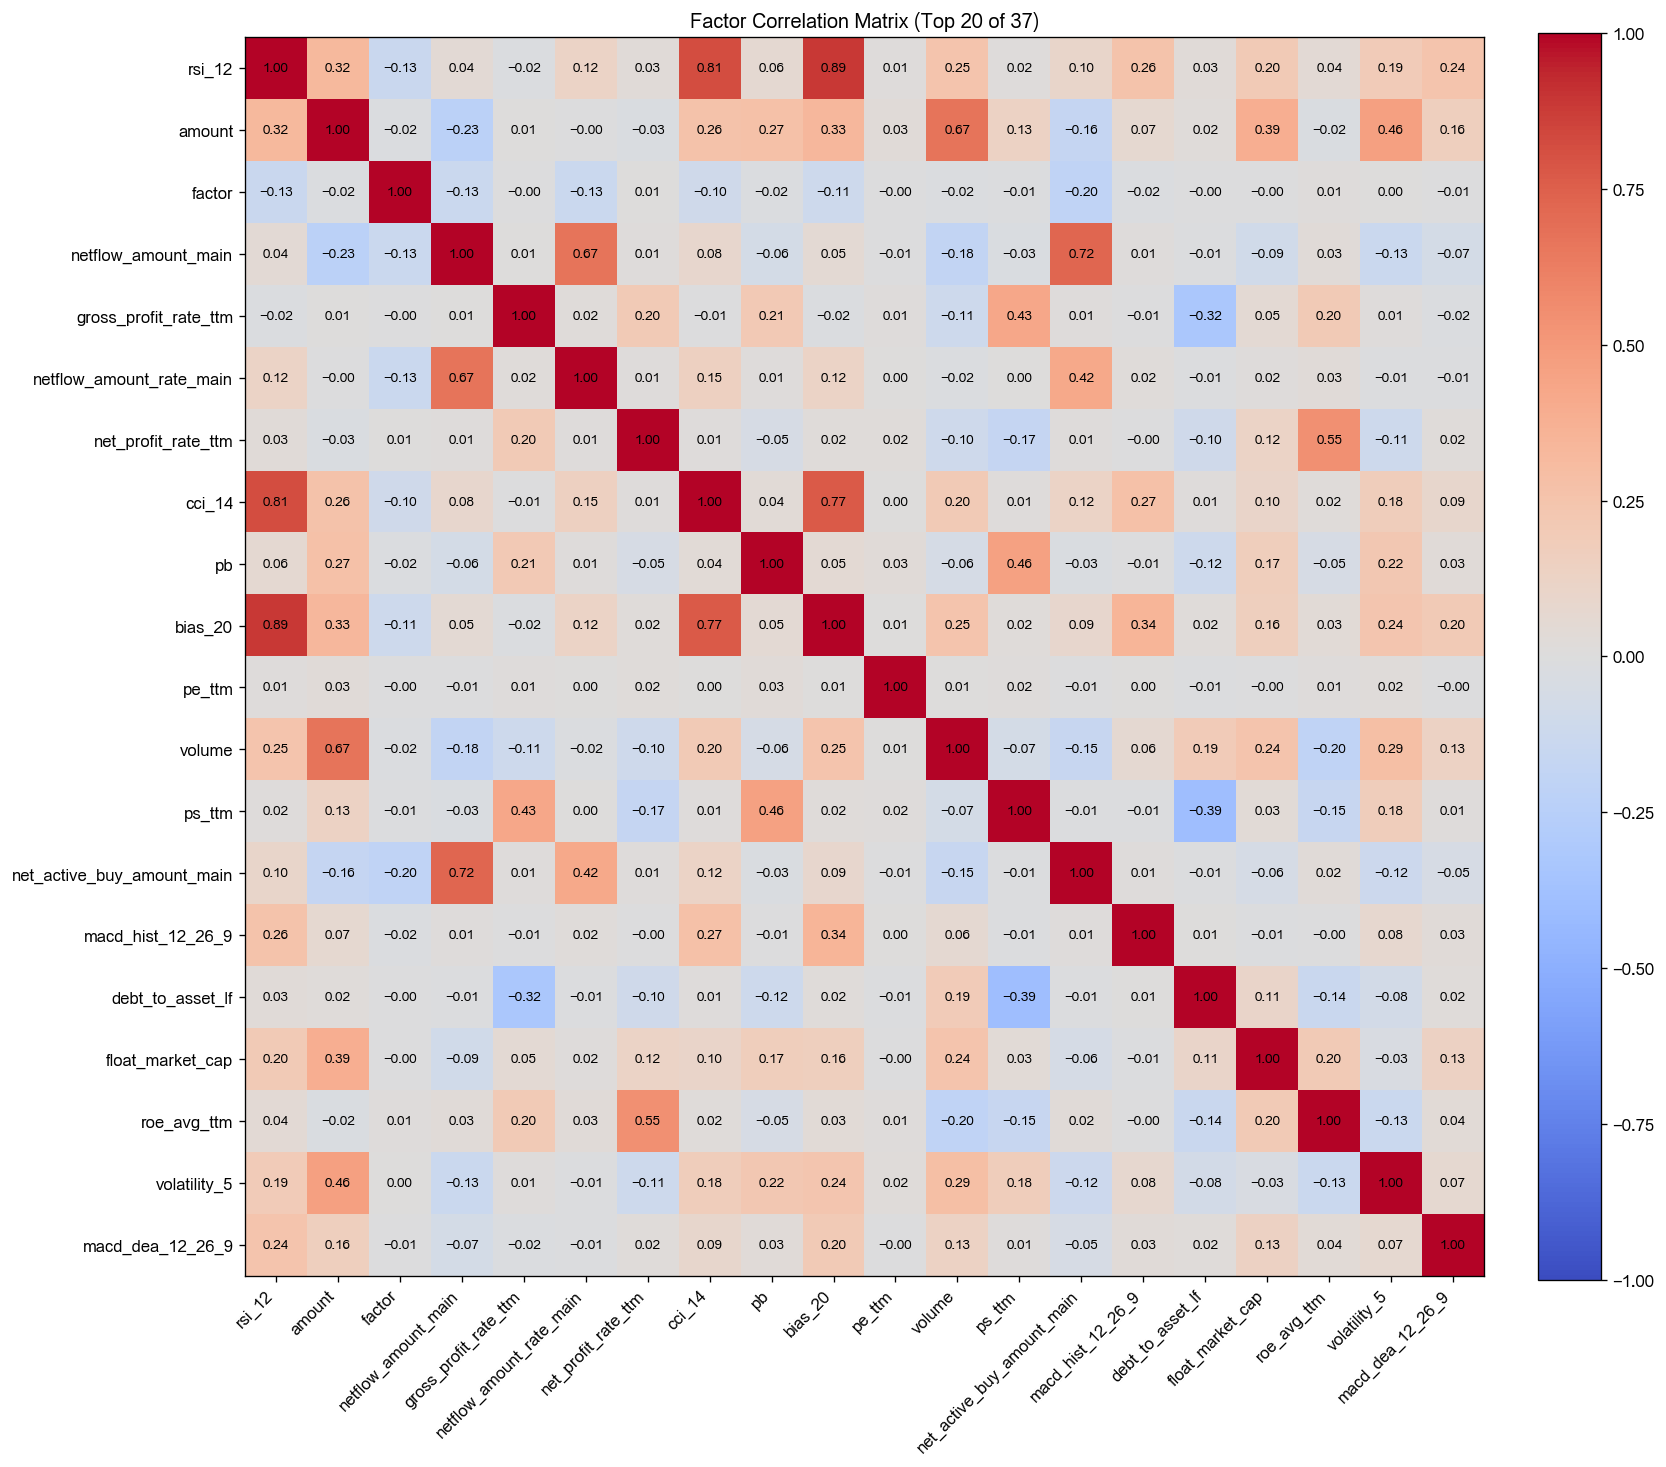

[2026-07-08 15:36:54] [warning  ] 返回的Outputs实例(size=35467559) 大于 64K, 将不会被缓存
[2026-07-08 15:36:54] [info     ] bigalpha_eval.v4 运行完成 [22.989s].


In [2]:
import dai
import pandas as pd
import numpy as np


def main(datasources, start_date, end_date):
    bar1m = datasources["bar1m"]

    # ── 单层 GROUP BY：仿 orderbook_pressure_v2 已验证结构 ──
    sql = f"""
    SELECT
        date_trunc('day', date)::DATE AS date,
        instrument::STRING AS instrument,
        ARG_MIN(open, date) AS open,
        ARG_MAX(close, date) AS close,
        MAX(high) AS high,
        MIN(low) AS low,
        -AVG(
            (
                1.000 * (bid_volume1 - ask_volume1) +
                0.741 * (bid_volume2 - ask_volume2) +
                0.549 * (bid_volume3 - ask_volume3) +
                0.407 * (bid_volume4 - ask_volume4) +
                0.301 * (bid_volume5 - ask_volume5)
            )
            / NULLIF(
                1.000 * (bid_volume1 + ask_volume1) +
                0.741 * (bid_volume2 + ask_volume2) +
                0.549 * (bid_volume3 + ask_volume3) +
                0.407 * (bid_volume4 + ask_volume4) +
                0.301 * (bid_volume5 + ask_volume5),
                0
            )
        ) * (2.0 - AVG(
            (bid_volume1 + bid_volume2 + bid_volume3 + bid_volume4 + bid_volume5)
            / NULLIF(ask_volume1 + ask_volume2 + ask_volume3 + ask_volume4 + ask_volume5, 0)
        )) AS ob_pressure
    FROM {bar1m}
    WHERE date BETWEEN '{start_date}' AND '{end_date}'
      AND bid_volume1 > 0 AND ask_volume1 > 0
    GROUP BY date_trunc('day', date)::DATE, instrument::STRING
    """

    df = dai.query(sql, filters={"date": [start_date, end_date]}, compression=True).df()
    df["date"] = pd.to_datetime(df["date"])
    df["instrument"] = df["instrument"].astype(str)

    for col in ["open", "close", "high", "low", "ob_pressure"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # ── 日内收盘位置（来自日内动量 v2 的成功要素） ──
    df["close_pos"] = (df["close"] - df["low"]) / (df["high"] - df["low"] + 1e-12)

    # ── 截面标准化 ──
    def zscore(s):
        return (s - s.mean()) / (s.std() + 1e-12)

    df["z_ob"]       = df.groupby("date")["ob_pressure"].transform(zscore)
    df["z_close_pos"] = df.groupby("date")["close_pos"].transform(zscore)

    # ── 交互项：非线性方向确认 ──
    df["interaction"] = df["z_close_pos"] * df["z_ob"]
    df["z_inter"]    = df.groupby("date")["interaction"].transform(zscore)

    # ── 最终因子 ──
    df["factor"] = 0.7 * df["z_ob"] + 0.3 * df["z_inter"]
    df["factor"] = df["factor"].replace([np.inf, -np.inf], np.nan)

    # ── 对齐中证 1000 成分股 ──
    stk_pool = dai.query(
        f"""SELECT date, instrument
           FROM bigalpha_2026_instruments
           WHERE date BETWEEN '{start_date}' AND '{end_date}'""",
        filters={"date": [start_date, end_date]},
        compression=True,
    ).df()
    stk_pool["date"] = pd.to_datetime(stk_pool["date"])
    stk_pool["instrument"] = stk_pool["instrument"].astype(str)

    result = pd.merge(
        stk_pool,
        df[["date", "instrument", "factor"]],
        on=["date", "instrument"],
        how="left",
    )
    result["factor"] = pd.to_numeric(result["factor"], errors="coerce")
    result["factor"] = result["factor"].replace([np.inf, -np.inf], np.nan)
    result["factor"] = result.groupby("date")["factor"].transform(
        lambda x: x.fillna(x.median())
    )
    result["factor"] = result["factor"].fillna(0)

    return result[["date", "instrument", "factor"]].copy()


if __name__ == "__main__":
    from bigmodule import M

    datasources = {"bar1m": "bigalpha_2026_stock_bar1m"}
    start_date = "2024-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    factor_data = main(datasources, start_date, end_date)
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )